_IMPORTACION DE LIBRERIAS_

In [11]:
import pandas as pd
from spacy import displacy
from spacy.language import Language
from spacy_langdetect import LanguageDetector
from tqdm import tqdm
import dask.dataframe as dd
from dask.diagnostics import ProgressBar
from collections import Counter
import seaborn as sns
from matplotlib import colors, pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.preprocessing import MinMaxScaler
import numpy as np

_CARGA DEL FICHERO_

In [12]:
df_original = pd.read_csv("data/out.csv")

_EXAMEN INICIAL_

In [13]:
print(df_original.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   A           10000 non-null  int64  
 1   B           10000 non-null  int64  
 2   C           10000 non-null  int64  
 3   D           10000 non-null  int64  
 4   E           10000 non-null  int64  
 5   comentario  10000 non-null  object 
 6   label       10000 non-null  float64
 7   A_t         10000 non-null  float64
 8   B_t         10000 non-null  float64
 9   C_t         10000 non-null  float64
 10  D_t         10000 non-null  float64
 11  E_t         10000 non-null  float64
 12  Valor_1     10000 non-null  float64
 13  Valor_2     10000 non-null  float64
 14  Valor_3     10000 non-null  float64
 15  Valor_4     10000 non-null  float64
 16  Valor_5     10000 non-null  float64
 17  Valor_6     10000 non-null  float64
 18  Valor_7     10000 non-null  float64
 19  Valor_8     10000 non-null

In [14]:
print(df_original.describe())

                  A             B             C             D             E  \
count  10000.000000  10000.000000  10000.000000  10000.000000  10000.000000   
mean       0.957400     26.098100      5.674600      0.091300      2.200600   
std        1.741864     34.012341      7.317149      0.352671      2.729488   
min        0.000000      0.000000      0.000000      0.000000      0.000000   
25%        0.000000      1.000000      1.000000      0.000000      0.000000   
50%        0.000000      5.000000      3.000000      0.000000      0.000000   
75%        1.000000     46.000000      7.000000      0.000000      6.000000   
max       24.000000    328.000000     88.000000      6.000000      6.000000   

              label           A_t           B_t           C_t           D_t  \
count  10000.000000  10000.000000  10000.000000  10000.000000  10000.000000   
mean       0.500000      0.735989      0.895389      1.014276     -0.241571   
std        0.500025      1.863010      1.672944    

In [15]:
print("\nNulos por columna: ")
print(df_original.isnull().sum())


Nulos por columna: 
A             0
B             0
C             0
D             0
E             0
comentario    0
label         0
A_t           0
B_t           0
C_t           0
D_t           0
E_t           0
Valor_1       0
Valor_2       0
Valor_3       0
Valor_4       0
Valor_5       0
Valor_6       0
Valor_7       0
Valor_8       0
Valor_9       0
Valor_10      0
dtype: int64


In [16]:
print(df_original.head(1))

   A   B   C  D  E                                         comentario  label  \
0  2  64  30  0  2  pandemia,originado,covid,cierto,incidencia,aba...    0.0   

        A_t       B_t       C_t  ...   Valor_1   Valor_2   Valor_3   Valor_4  \
0  1.851102  2.759647  7.145831  ...  5.108388  13.22766 -0.771127  0.815665   

    Valor_5   Valor_6   Valor_7  Valor_8   Valor_9  Valor_10  
0  19.71997 -1.149606  1.216004 -2.97679  3.148722  -0.18356  

[1 rows x 22 columns]


_ELIMINAMOS LA COLUMNA DE INFORMACION DE TEXTO PARA ANALIZAR LAS FEATURES_

Las caracteristicas que tenemos son:

    'A',        # wb_bigram_count: conteo de bigramas
    'B',        # wb_pos_count: conteo de palabras positivas
    'C',        # wb_neg_count: conteo de palabras negativas
    'D',        # mentions_count: conteo de menciones (@)
    'E',        # sentiment_cat: categoría de sentimiento (0-6)
    'label',    # OBJETIVO
    'A_t',      # bigramas normalizados
    'B_t',      # palabras positivas normalizadas
    'C_t',      # palabras negativas normalizadas
    'D_t',      # menciones normalizadas
    'E_t',      # sentimiento normalizado

Las caracteristicas 'Valor_1',...'Valor_10' son caracteristicas generadas a traves de una tecnica de "Feature Engineering", multiplicando pares de caracteristicas existentes (A, B, C, D, E normalizdas) entre si, ayudando a capturar relaciones no lineales entre las características originales.

In [17]:
data_EDA = df_original.drop('comentario', axis=1)
#data_EDA = df_original


In [18]:
print(data_EDA.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   A         10000 non-null  int64  
 1   B         10000 non-null  int64  
 2   C         10000 non-null  int64  
 3   D         10000 non-null  int64  
 4   E         10000 non-null  int64  
 5   label     10000 non-null  float64
 6   A_t       10000 non-null  float64
 7   B_t       10000 non-null  float64
 8   C_t       10000 non-null  float64
 9   D_t       10000 non-null  float64
 10  E_t       10000 non-null  float64
 11  Valor_1   10000 non-null  float64
 12  Valor_2   10000 non-null  float64
 13  Valor_3   10000 non-null  float64
 14  Valor_4   10000 non-null  float64
 15  Valor_5   10000 non-null  float64
 16  Valor_6   10000 non-null  float64
 17  Valor_7   10000 non-null  float64
 18  Valor_8   10000 non-null  float64
 19  Valor_9   10000 non-null  float64
 20  Valor_10  10000 non-null  flo

_OUTLIERS DE CARACTERISTICAS_

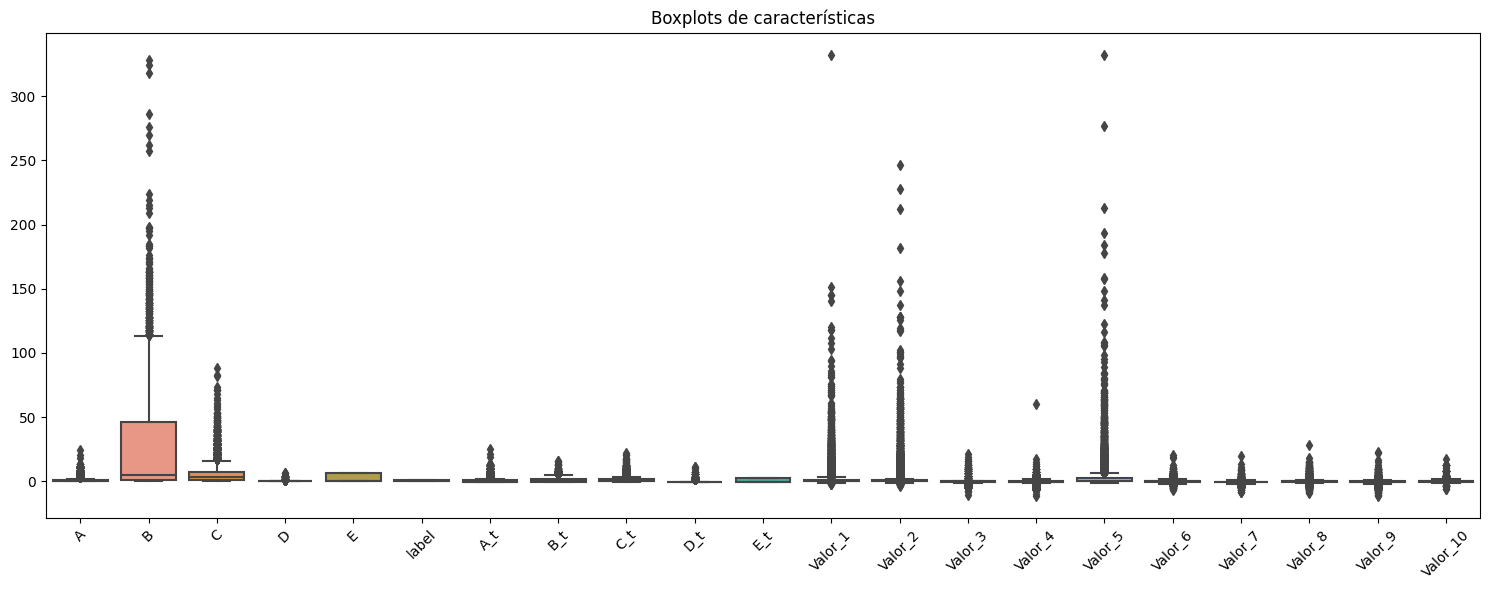

In [19]:
# Boxplots para visualizar outliers
plt.figure(figsize=(15, 6))
sns.boxplot(data=data_EDA)
plt.xticks(rotation=45)
plt.title('Boxplots de características')
plt.tight_layout()
plt.show()


Outliers usando método IQR:
          n_outliers  percentage  lower_bound  upper_bound
A               1229       12.29        -1.50         2.50
B                194        1.94       -66.50       113.50
C                780        7.80        -8.00        16.00
D                764        7.64         0.00         0.00
E                  0        0.00        -9.00        15.00
label              0        0.00        -1.50         2.50
A_t             1229       12.29        -1.89         2.39
B_t              194        1.94        -3.66         5.19
C_t              780        7.80        -2.43         3.62
D_t              764        7.64        -0.42        -0.42
E_t                0        0.00        -4.90         6.76
Valor_1         1733       17.33        -1.95         3.02
Valor_2         2067       20.67        -1.23         1.80
Valor_3          971        9.71        -1.26         0.95
Valor_4         1371       13.71        -1.95         1.41
Valor_5         1405       

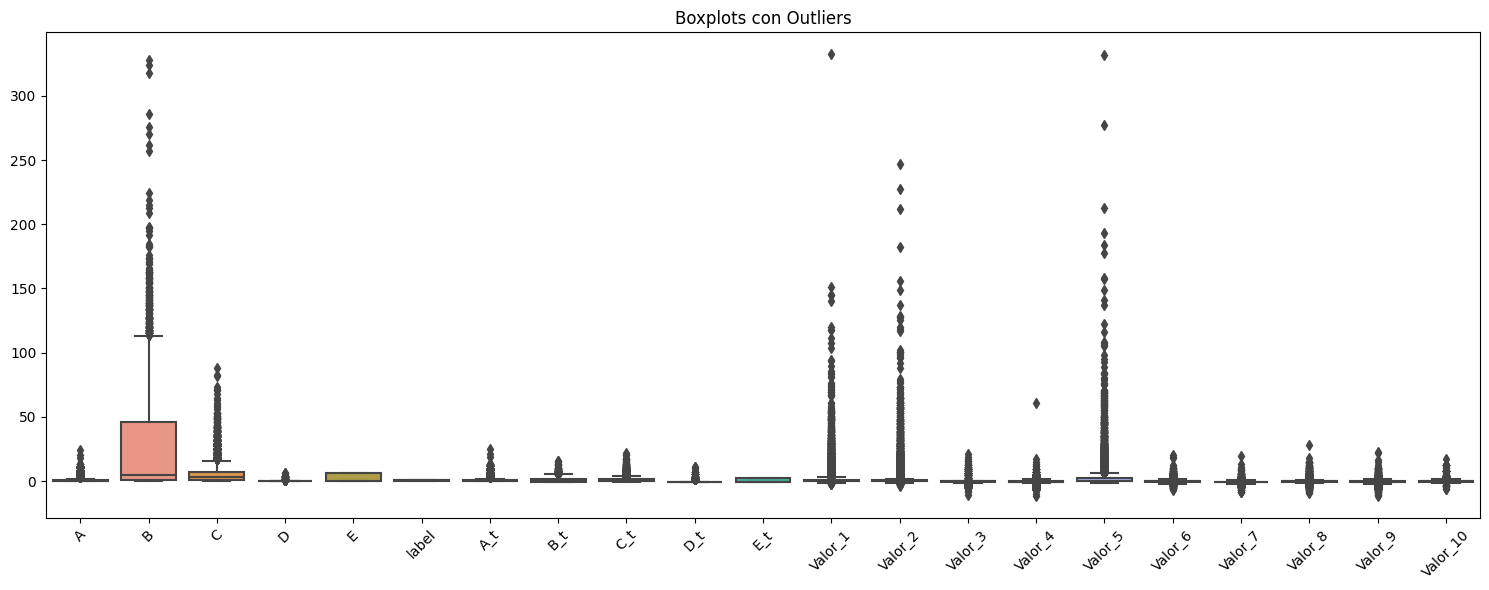

/home/sgomez/.cache/pypoetry/virtualenvs/unir-msc-ai-AuZ9bGHS-py3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/sgomez/.cache/pypoetry/virtualenvs/unir-msc-ai-AuZ9bGHS-py3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/sgomez/.cache/pypoetry/virtualenvs/unir-msc-ai-AuZ9bGHS-py3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/sgomez/.cache/pypoetry/virtuale

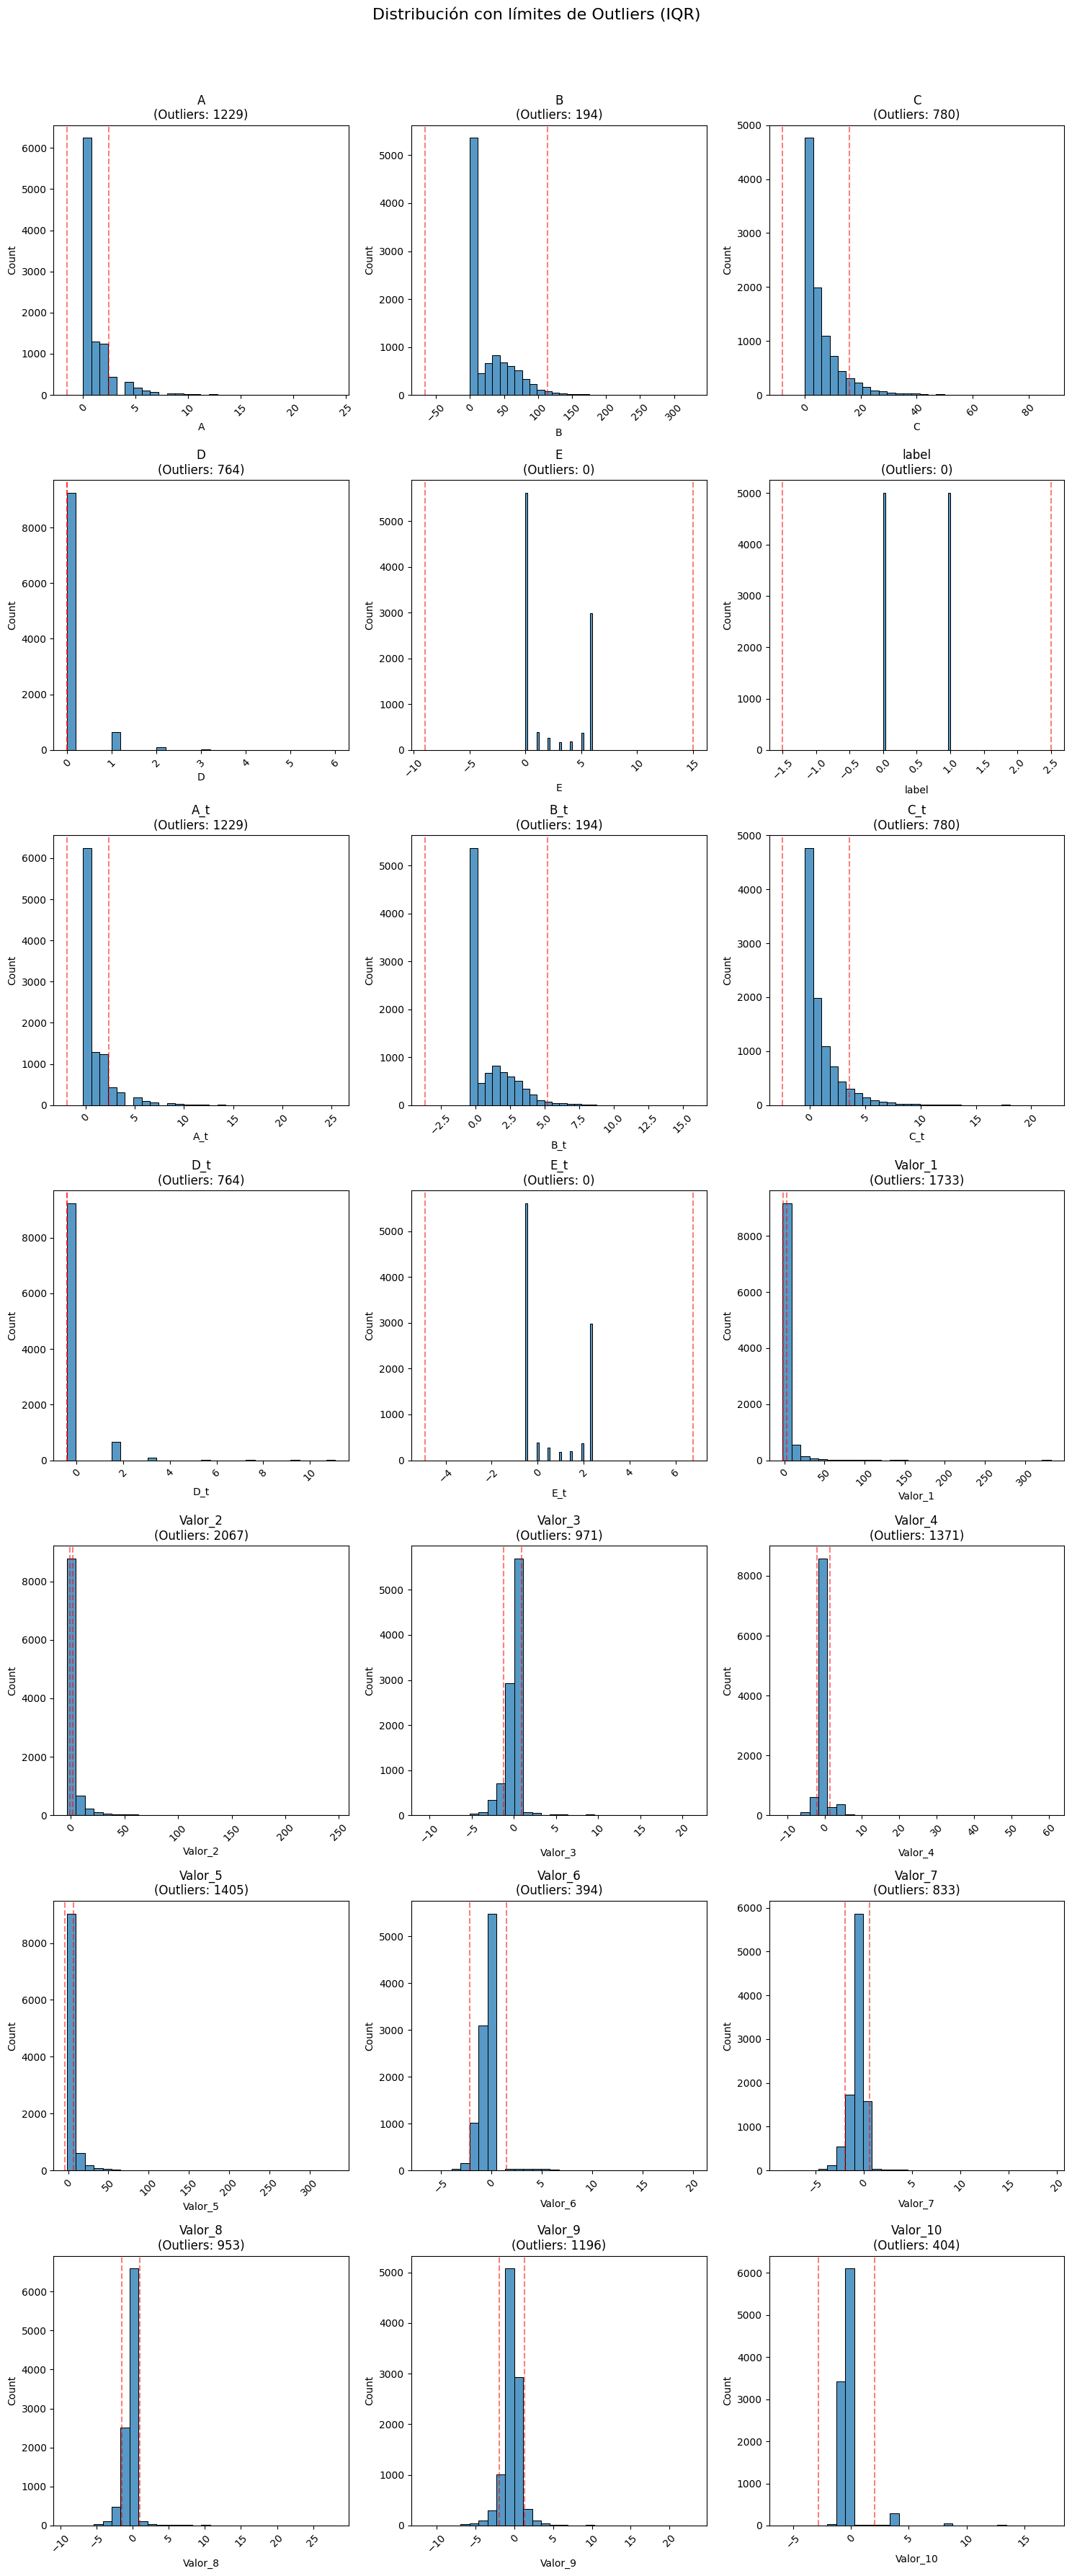


Resumen estadístico de los datos:
                  A             B             C             D             E  \
count  10000.000000  10000.000000  10000.000000  10000.000000  10000.000000   
mean       0.957400     26.098100      5.674600      0.091300      2.200600   
std        1.741864     34.012341      7.317149      0.352671      2.729488   
min        0.000000      0.000000      0.000000      0.000000      0.000000   
25%        0.000000      1.000000      1.000000      0.000000      0.000000   
50%        0.000000      5.000000      3.000000      0.000000      0.000000   
75%        1.000000     46.000000      7.000000      0.000000      6.000000   
max       24.000000    328.000000     88.000000      6.000000      6.000000   

              label           A_t           B_t           C_t           D_t  \
count  10000.000000  10000.000000  10000.000000  10000.000000  10000.000000   
mean       0.500000      0.735989      0.895389      1.014276     -0.241571   
std        0.500

In [20]:
import numpy as np
import pandas as pd

def calculate_outliers(df, method='iqr'):
    """
    Calcula outliers usando diferentes métodos
    method: 'iqr' para rango intercuartil o 'zscore' para z-score
    """
    outliers_summary = {}
    
    if method == 'iqr':
        # Método IQR (Rango Intercuartil)
        for column in df.columns:
            Q1 = df[column].quantile(0.25)
            Q3 = df[column].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            
            outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)][column]
            
            outliers_summary[column] = {
                'n_outliers': len(outliers),
                'percentage': (len(outliers) / len(df)) * 100,
                'lower_bound': lower_bound,
                'upper_bound': upper_bound
            }
            
    elif method == 'zscore':
        # Método Z-score
        for column in df.columns:
            z_scores = np.abs((df[column] - df[column].mean()) / df[column].std())
            outliers = df[z_scores > 3][column]  # Umbral de 3 desviaciones estándar
            
            outliers_summary[column] = {
                'n_outliers': len(outliers),
                'percentage': (len(outliers) / len(df)) * 100
            }
    
    return outliers_summary

# Calcular outliers usando ambos métodos
iqr_outliers = calculate_outliers(data_EDA, method='iqr')
zscore_outliers = calculate_outliers(data_EDA, method='zscore')

# Crear DataFrames para mostrar los resultados
iqr_results = pd.DataFrame.from_dict(iqr_outliers, orient='index')
zscore_results = pd.DataFrame.from_dict(zscore_outliers, orient='index')

# Mostrar resultados
print("\nOutliers usando método IQR:")
print(iqr_results.round(2))
print("\nOutliers usando método Z-score:")
print(zscore_results.round(2))

# Visualización de outliers
import matplotlib.pyplot as plt
import seaborn as sns

# Boxplots con puntos para outliers
plt.figure(figsize=(15, 6))
sns.boxplot(data=data_EDA)
plt.xticks(rotation=45)
plt.title('Boxplots con Outliers')
plt.tight_layout()
plt.show()

# Histogramas con límites de outliers (IQR)
n_cols = 3
n_rows = (len(data_EDA.columns) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
fig.suptitle('Distribución con límites de Outliers (IQR)', y=1.02, fontsize=16)

axes_flat = axes.flatten()

for idx, col in enumerate(data_EDA.columns):
    sns.histplot(data=data_EDA, x=col, ax=axes_flat[idx], bins=30)
    
    # Añadir líneas verticales para los límites de outliers
    if col in iqr_outliers:
        axes_flat[idx].axvline(iqr_outliers[col]['lower_bound'], color='r', linestyle='--', alpha=0.5)
        axes_flat[idx].axvline(iqr_outliers[col]['upper_bound'], color='r', linestyle='--', alpha=0.5)
    
    axes_flat[idx].set_title(f'{col}\n(Outliers: {iqr_outliers[col]["n_outliers"]})')
    axes_flat[idx].tick_params(axis='x', rotation=45)

# Eliminar subplots vacíos
for idx in range(len(data_EDA.columns), len(axes_flat)):
    fig.delaxes(axes_flat[idx])

plt.tight_layout()
plt.show()

# Resumen estadístico
print("\nResumen estadístico de los datos:")
print(data_EDA.describe())

_HISTOGRAMA DE CARACTERISTICAS_

/home/sgomez/.cache/pypoetry/virtualenvs/unir-msc-ai-AuZ9bGHS-py3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/sgomez/.cache/pypoetry/virtualenvs/unir-msc-ai-AuZ9bGHS-py3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/sgomez/.cache/pypoetry/virtualenvs/unir-msc-ai-AuZ9bGHS-py3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/sgomez/.cache/pypoetry/virtuale

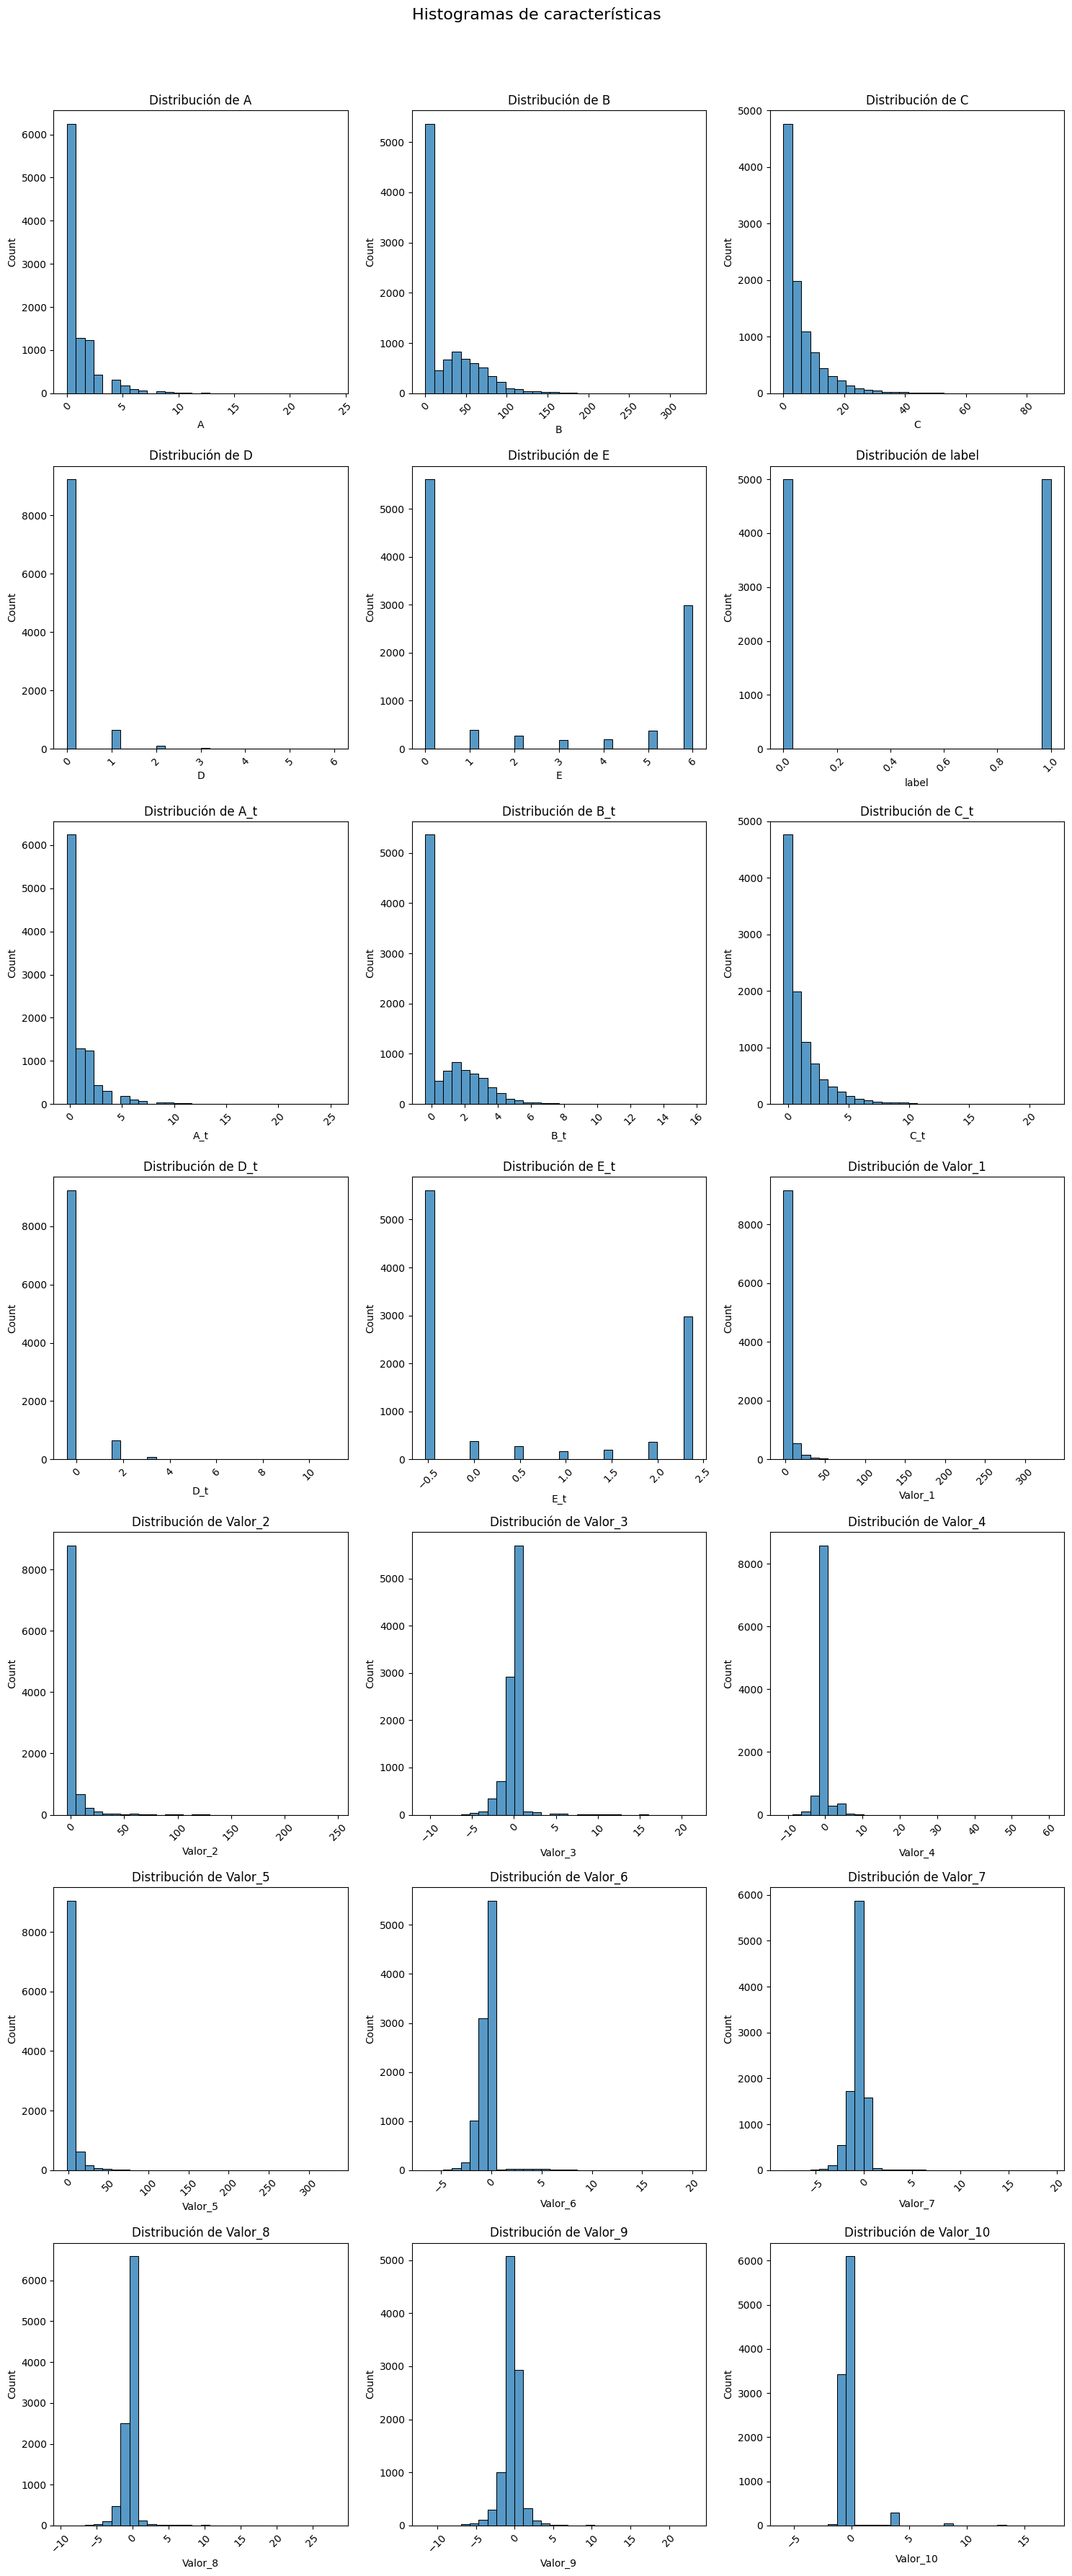

/home/sgomez/.cache/pypoetry/virtualenvs/unir-msc-ai-AuZ9bGHS-py3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/sgomez/.cache/pypoetry/virtualenvs/unir-msc-ai-AuZ9bGHS-py3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/sgomez/.cache/pypoetry/virtualenvs/unir-msc-ai-AuZ9bGHS-py3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/sgomez/.cache/pypoetry/virtuale

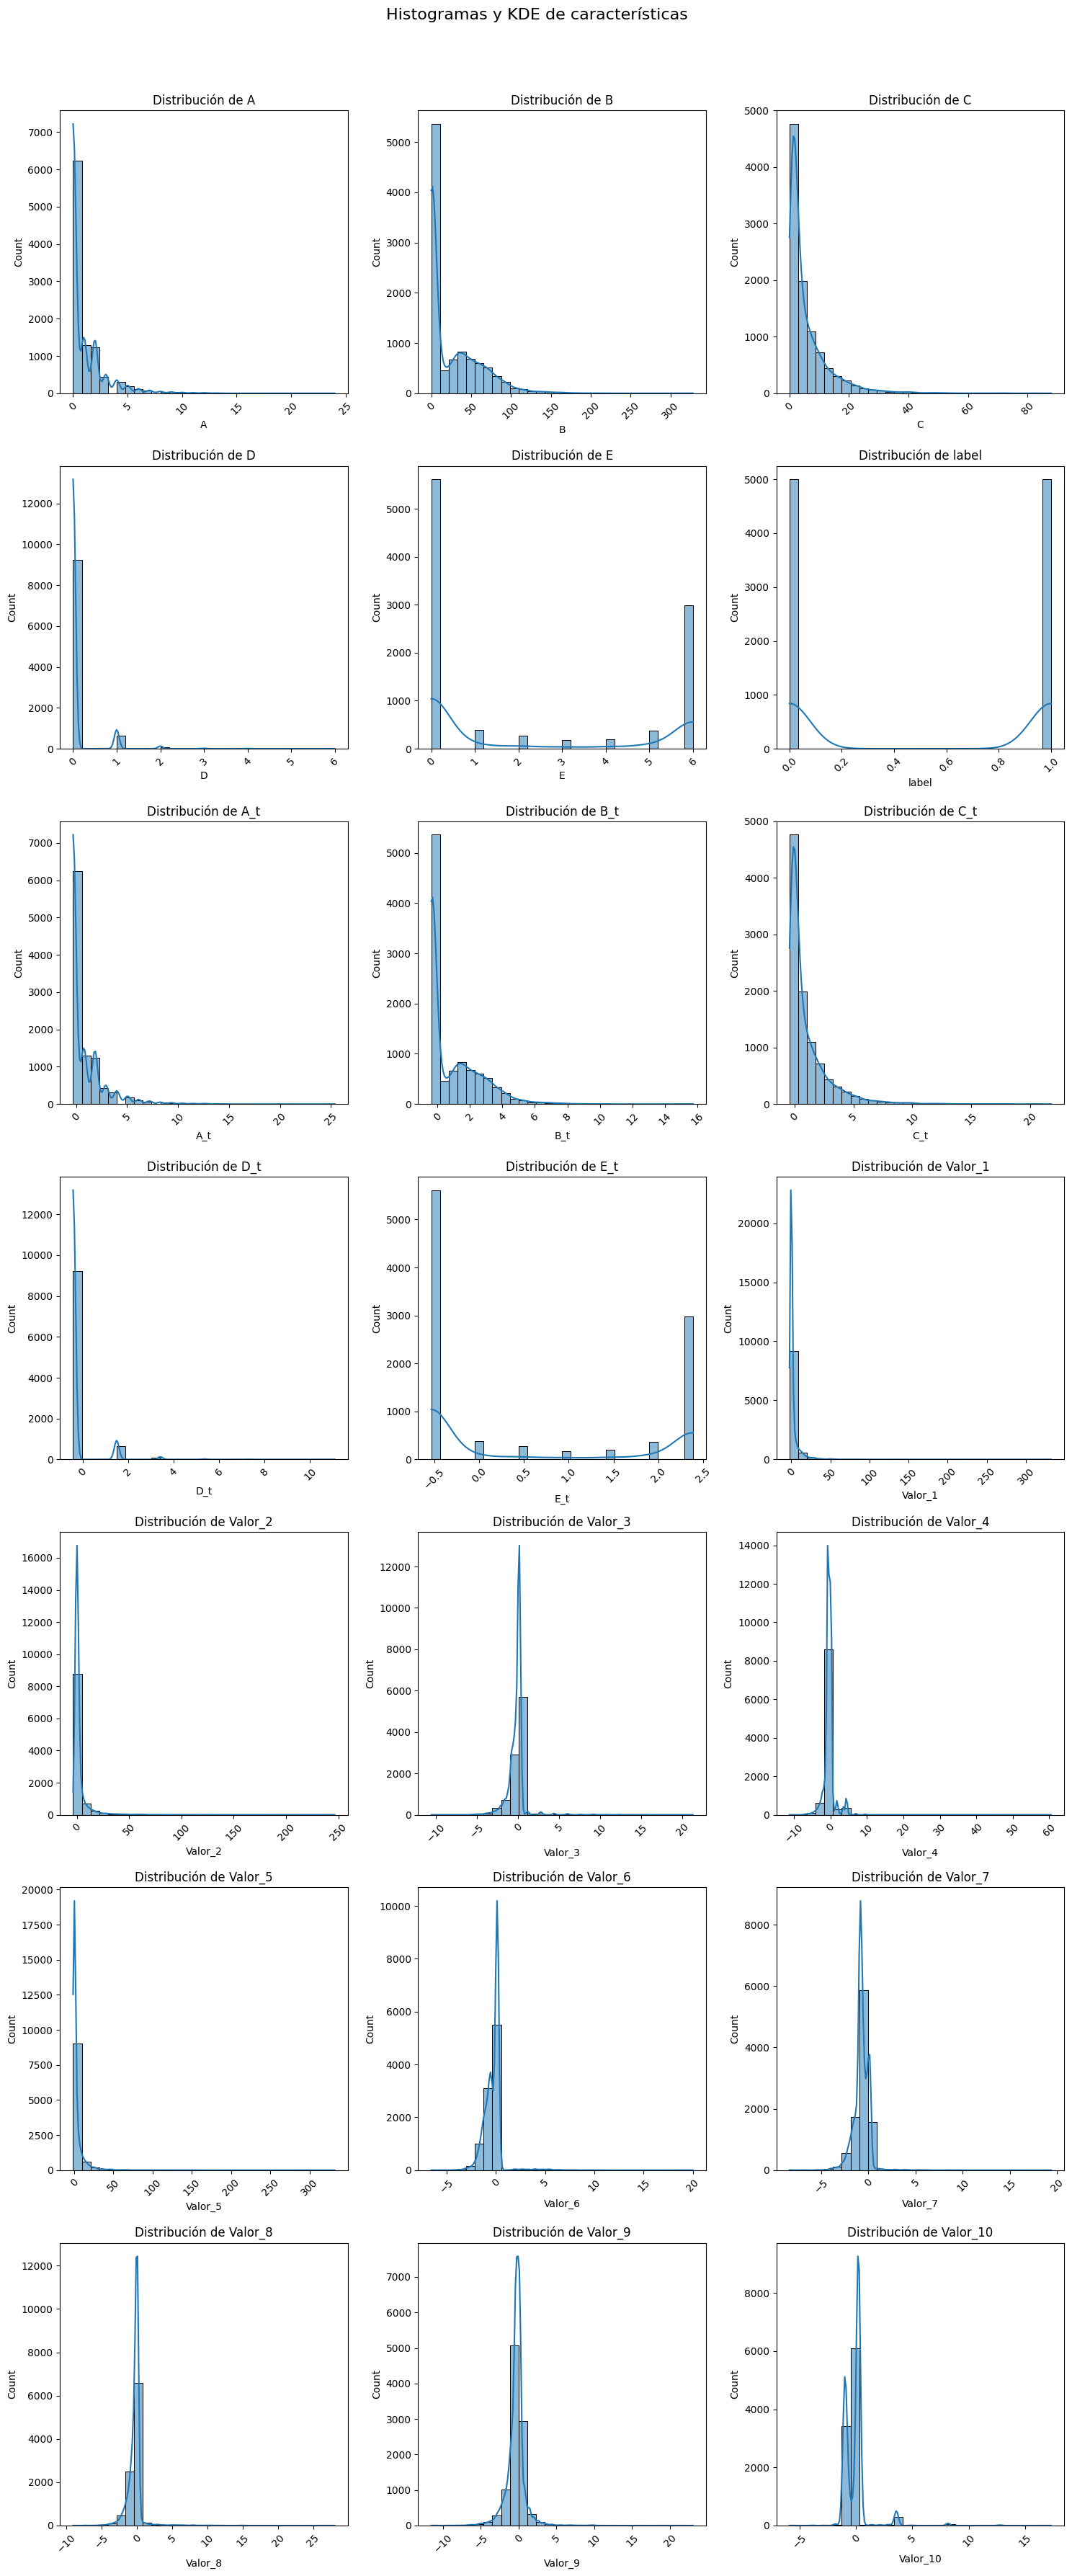


Estadísticas descriptivas:
                  A             B             C             D             E  \
count  10000.000000  10000.000000  10000.000000  10000.000000  10000.000000   
mean       0.957400     26.098100      5.674600      0.091300      2.200600   
std        1.741864     34.012341      7.317149      0.352671      2.729488   
min        0.000000      0.000000      0.000000      0.000000      0.000000   
25%        0.000000      1.000000      1.000000      0.000000      0.000000   
50%        0.000000      5.000000      3.000000      0.000000      0.000000   
75%        1.000000     46.000000      7.000000      0.000000      6.000000   
max       24.000000    328.000000     88.000000      6.000000      6.000000   

              label           A_t           B_t           C_t           D_t  \
count  10000.000000  10000.000000  10000.000000  10000.000000  10000.000000   
mean       0.500000      0.735989      0.895389      1.014276     -0.241571   
std        0.500025    

In [21]:
# Calcular número de filas necesarias
n_cols = 3
n_rows = (len(data_EDA.columns) + n_cols - 1) // n_cols

# Crear la figura
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
fig.suptitle('Histogramas de características', y=1.02, fontsize=16)

# Aplanar el array de axes si hay múltiples filas
axes_flat = axes.flatten()

# Crear histogramas
for idx, col in enumerate(data_EDA.columns):
    sns.histplot(data=data_EDA, x=col, ax=axes_flat[idx], bins=30)
    axes_flat[idx].set_title(f'Distribución de {col}')
    axes_flat[idx].tick_params(axis='x', rotation=45)

# Eliminar subplots vacíos si los hay
for idx in range(len(data_EDA.columns), len(axes_flat)):
    fig.delaxes(axes_flat[idx])

plt.tight_layout()
plt.show()

# 3. Versión con KDE (Kernel Density Estimation)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
fig.suptitle('Histogramas y KDE de características', y=1.02, fontsize=16)

axes_flat = axes.flatten()

for idx, col in enumerate(data_EDA.columns):
    sns.histplot(data=data_EDA, x=col, ax=axes_flat[idx], bins=30, kde=True)
    axes_flat[idx].set_title(f'Distribución de {col}')
    axes_flat[idx].tick_params(axis='x', rotation=45)

for idx in range(len(data_EDA.columns), len(axes_flat)):
    fig.delaxes(axes_flat[idx])

plt.tight_layout()
plt.show()

# 4. Estadísticas descriptivas
print("\nEstadísticas descriptivas:")
print(data_EDA.describe())


_DISTRIBUCION DE VARIABLES_

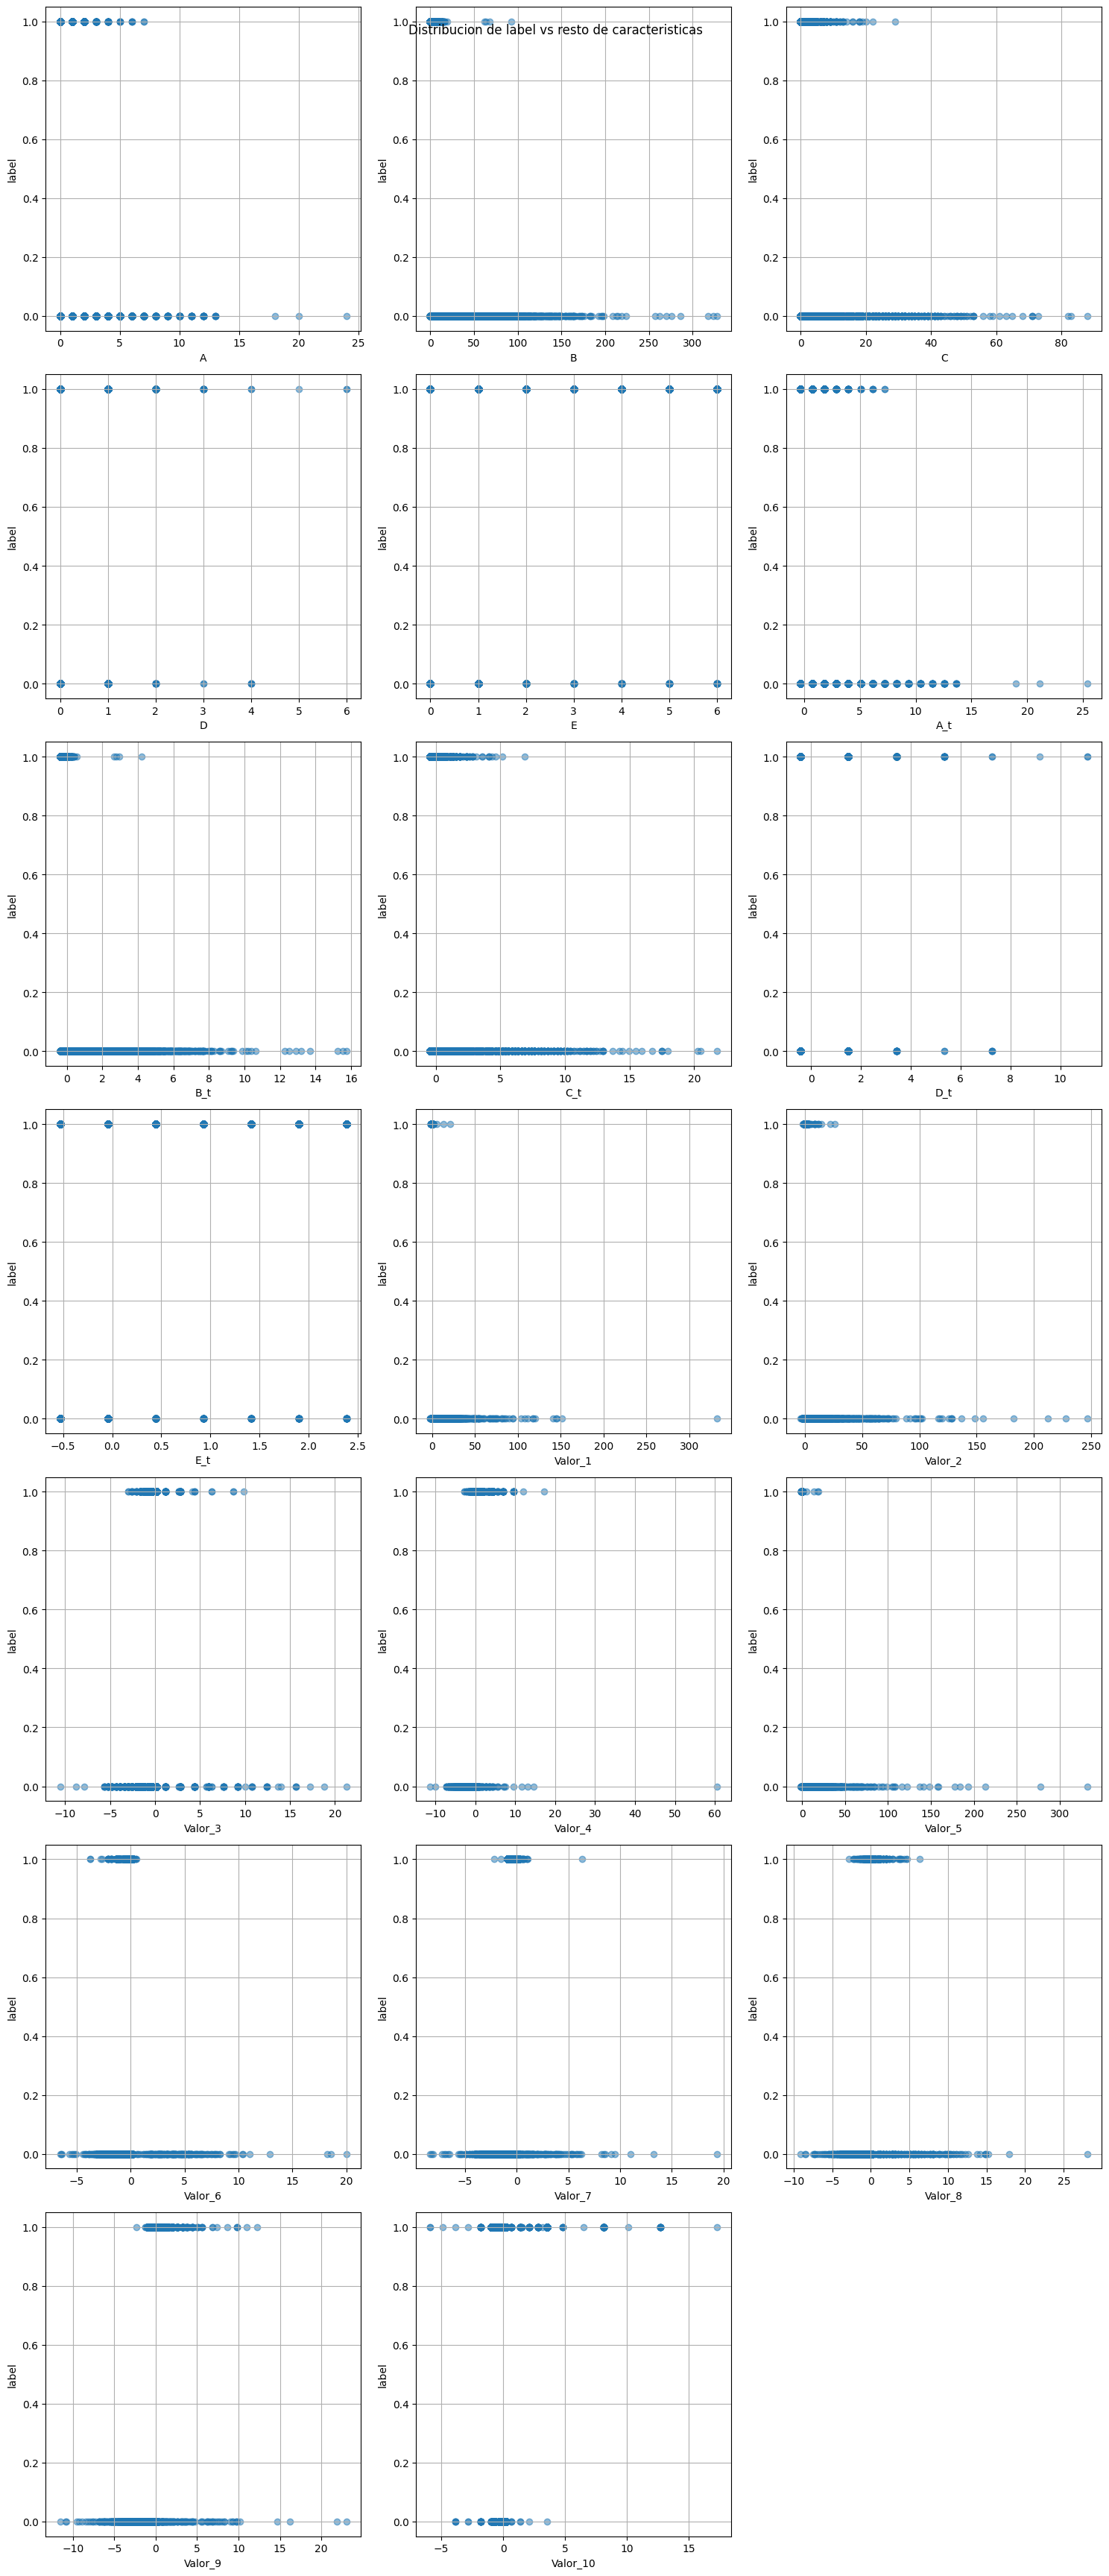

In [22]:
# Obtener las columnas numéricas excluyendo 'Date' y 'C6H6(GT)'
columnas = [col for col in data_EDA.columns if col not in ['label']]
n_cols = len(columnas)

# Calcular el número de filas y columnas necesarias
n_rows = (n_cols + 2) // 3  # Redondeo hacia arriba
n_cols = 3

# Crear una figura con el número correcto de subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
fig.suptitle('Distribucion de label vs resto de caracteristicas')

# Crear plots
for idx, col in enumerate(columnas):
    row = idx // 3
    col_idx = idx % 3
    axes[row, col_idx].scatter(data_EDA[col], data_EDA['label'], alpha=0.5)
    axes[row, col_idx].set_xlabel(col)
    axes[row, col_idx].set_ylabel('label')
    axes[row, col_idx].grid(True)

# Eliminar los subplots vacíos
for idx in range(len(columnas), n_rows * n_cols):
    row = idx // 3
    col_idx = idx % 3
    fig.delaxes(axes[row, col_idx])

# Ajustar el layout
plt.tight_layout()
plt.show()

_ELIMINACION DE OUTLIERS_

La decision de eliminar los outliers se puede dejar al albur de la prueba del modelo con o sin outliers; por ello, se dejara este codigo que se podra ejecutar de forma opcional para eliminar los outliers de los datos.

Eliminaremos los del metodo z-score.

Tamaño original: 10000
Tamaño después de eliminar outliers: 8736
Número de outliers eliminados: 1264
Porcentaje de datos eliminados: 12.64%


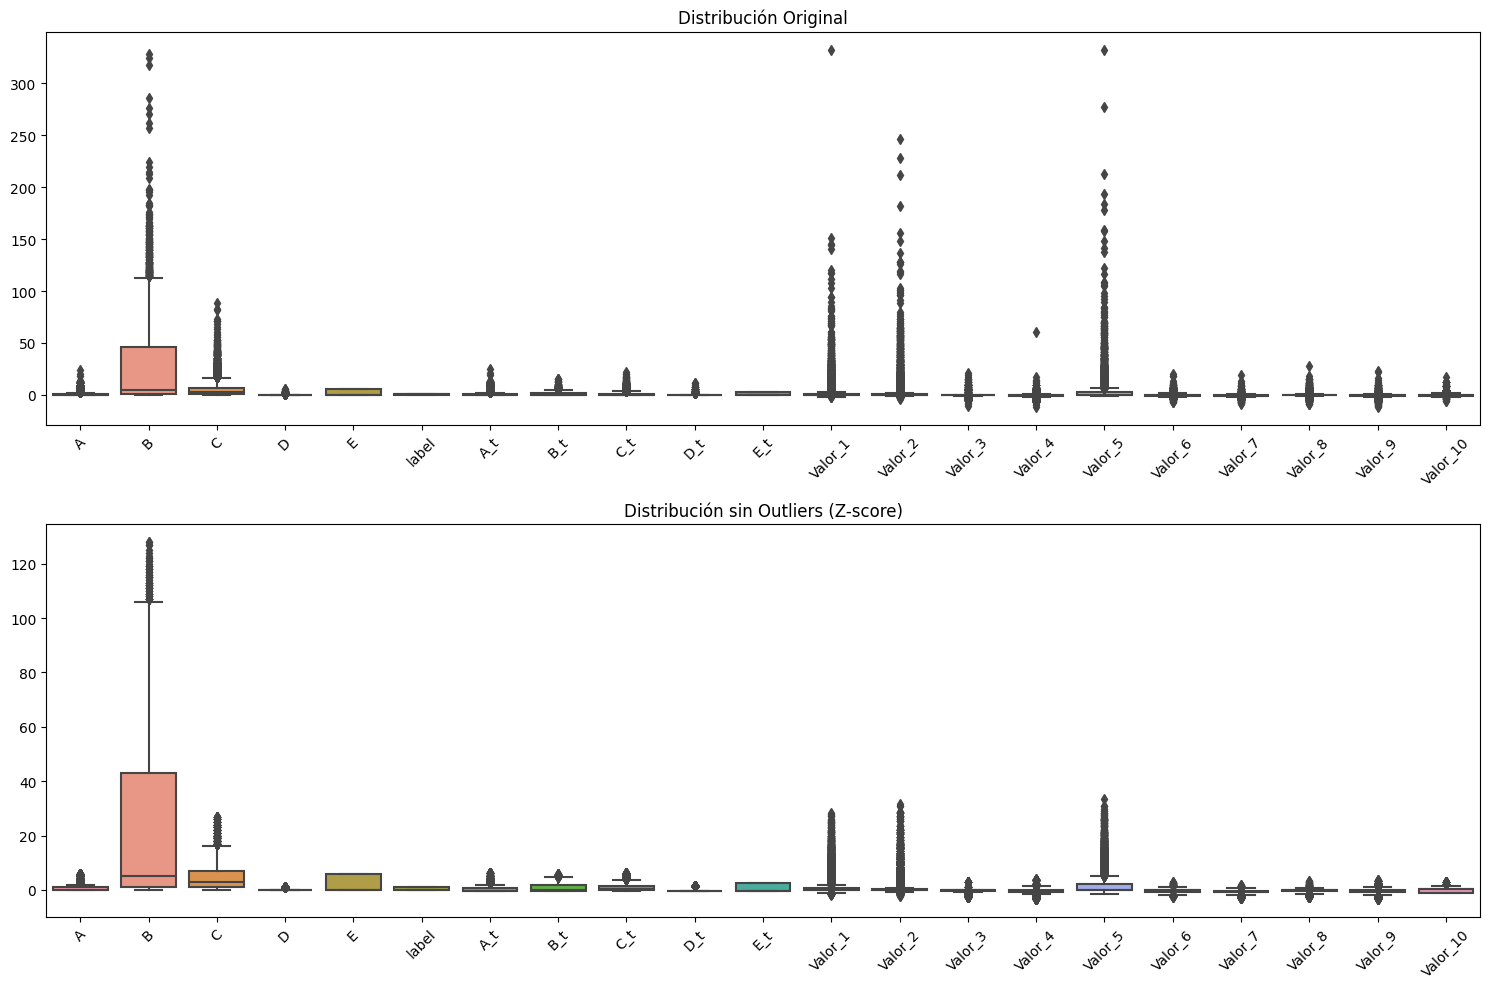

/home/sgomez/.cache/pypoetry/virtualenvs/unir-msc-ai-AuZ9bGHS-py3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/sgomez/.cache/pypoetry/virtualenvs/unir-msc-ai-AuZ9bGHS-py3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/sgomez/.cache/pypoetry/virtualenvs/unir-msc-ai-AuZ9bGHS-py3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/sgomez/.cache/pypoetry/virtuale

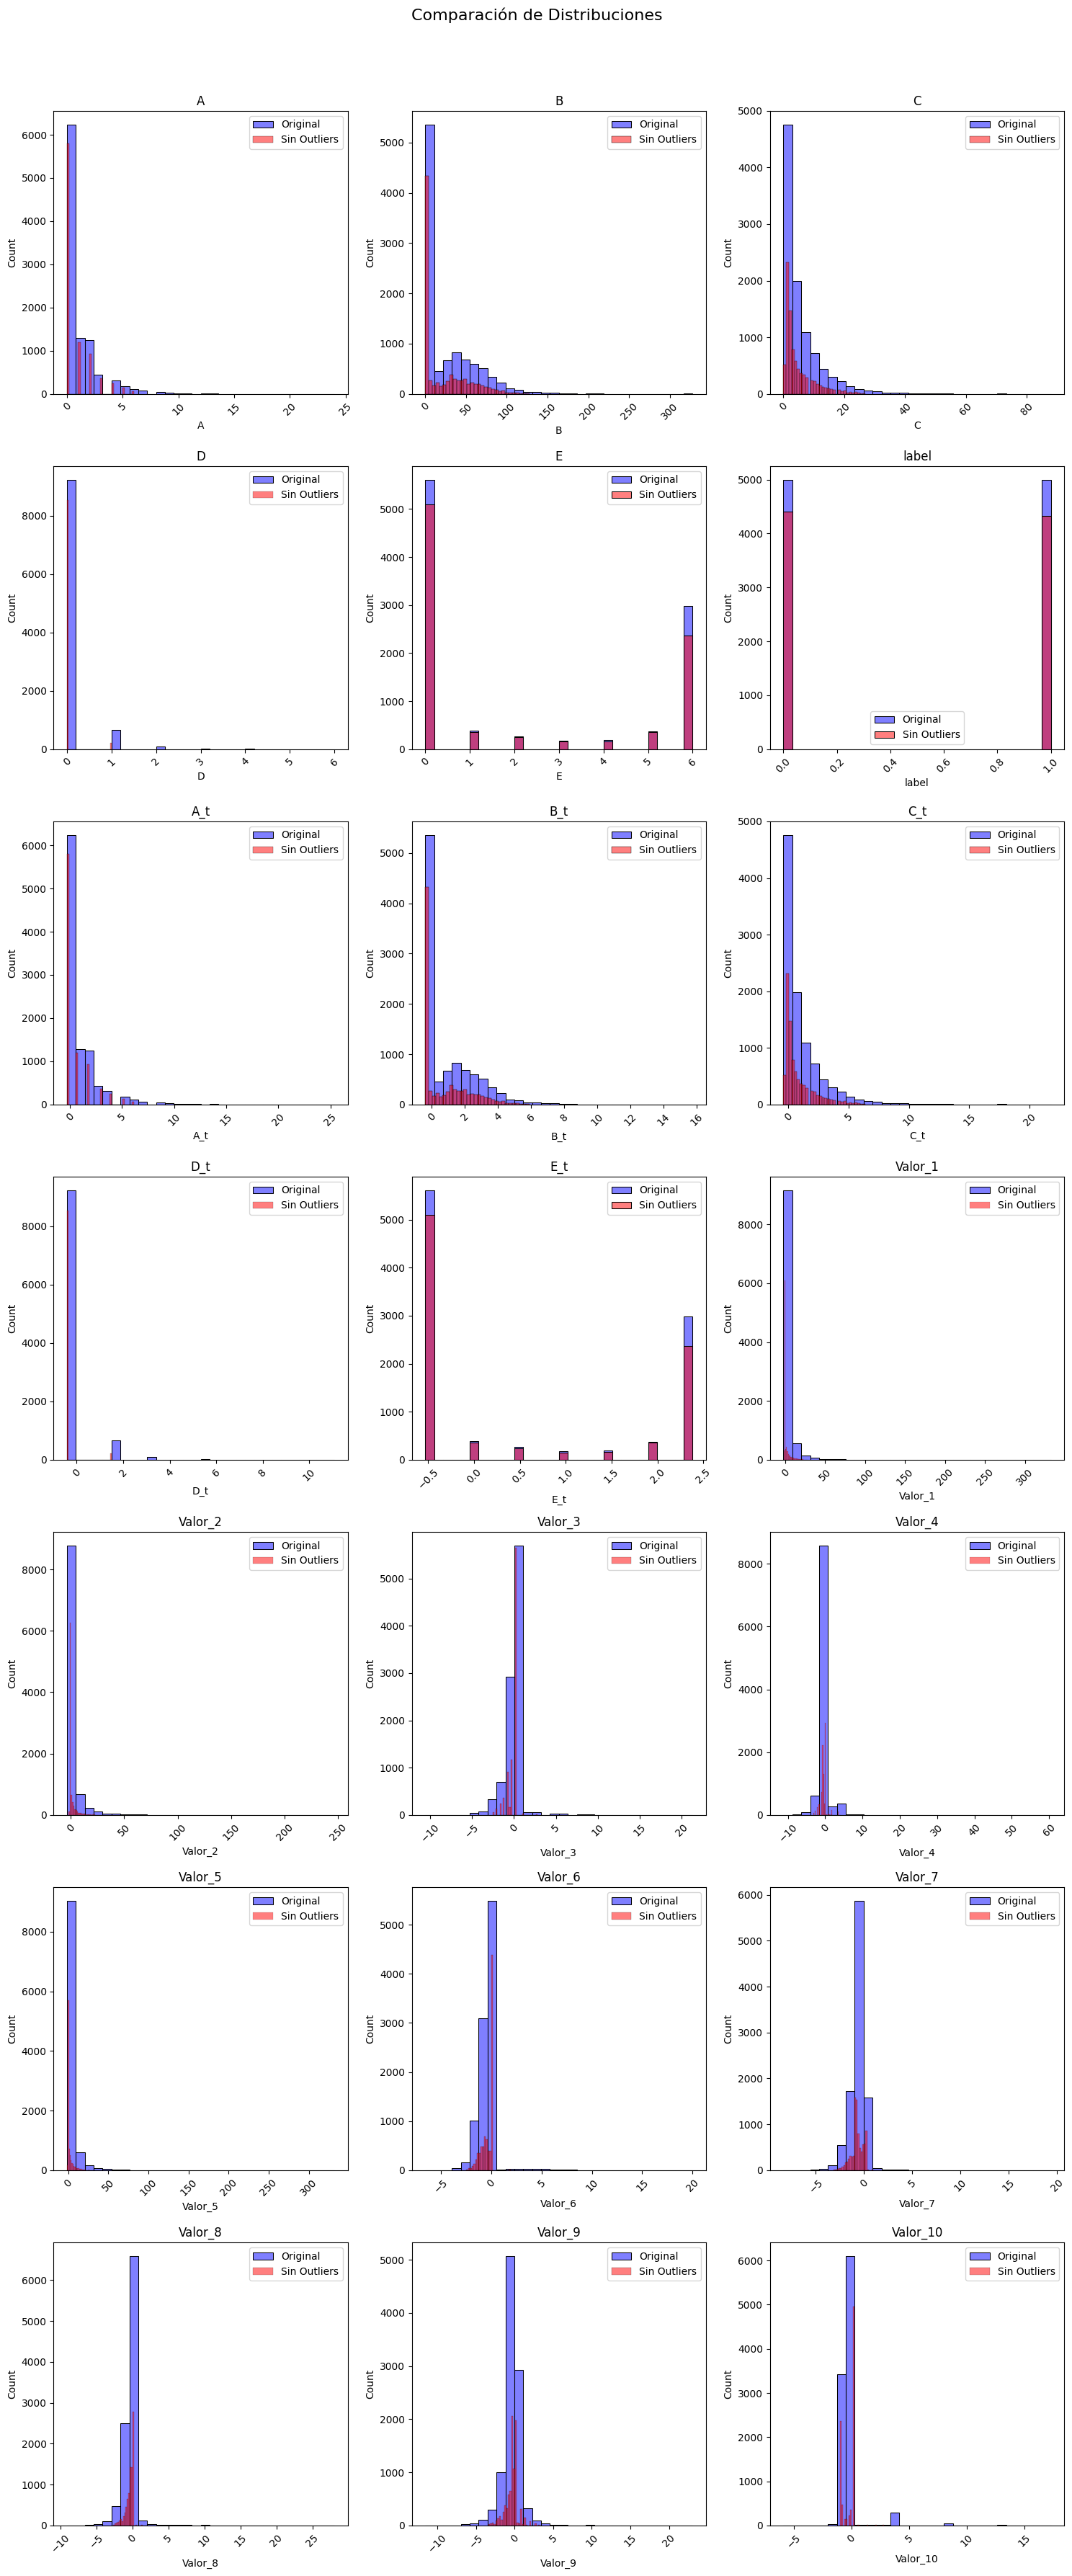


Estadísticas antes de eliminar outliers:
              A         B         C         D         E    label       A_t  \
count  10000.00  10000.00  10000.00  10000.00  10000.00  10000.0  10000.00   
mean       0.96     26.10      5.67      0.09      2.20      0.5      0.74   
std        1.74     34.01      7.32      0.35      2.73      0.5      1.86   
min        0.00      0.00      0.00      0.00      0.00      0.0     -0.29   
25%        0.00      1.00      1.00      0.00      0.00      0.0     -0.29   
50%        0.00      5.00      3.00      0.00      0.00      0.5     -0.29   
75%        1.00     46.00      7.00      0.00      6.00      1.0      0.78   
max       24.00    328.00     88.00      6.00      6.00      1.0     25.38   

            B_t       C_t       D_t  ...   Valor_1   Valor_2   Valor_3  \
count  10000.00  10000.00  10000.00  ...  10000.00  10000.00  10000.00   
mean       0.90      1.01     -0.24  ...      2.45      2.52     -0.22   
std        1.67      1.84      0.

In [23]:
import numpy as np
import pandas as pd
from scipy import stats

def remove_outliers_zscore(df, threshold=3):
    """
    Elimina outliers usando el método z-score
    
    Parámetros:
    df: DataFrame original
    threshold: número de desviaciones estándar (default=3)
    
    Retorna:
    DataFrame sin outliers
    """
    # Crear copia del DataFrame
    df_clean = df.copy()
    
    # Calcular z-scores
    z_scores = stats.zscore(df_clean)
    
    # Crear máscara para valores dentro del umbral
    mask = np.abs(z_scores) < threshold
    
    # Aplicar máscara y retornar DataFrame limpio
    return df_clean[mask.all(axis=1)]

# Aplicar la función
data_EDA_clean = remove_outliers_zscore(data_EDA, threshold=3)

# Mostrar información sobre los datos eliminados
print("Tamaño original:", len(data_EDA))
print("Tamaño después de eliminar outliers:", len(data_EDA_clean))
print("Número de outliers eliminados:", len(data_EDA) - len(data_EDA_clean))
print("Porcentaje de datos eliminados: {:.2f}%".format(
    (len(data_EDA) - len(data_EDA_clean)) / len(data_EDA) * 100
))

# Visualización antes y después
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))

# Boxplot original
sns.boxplot(data=data_EDA, ax=ax1)
ax1.set_title('Distribución Original')
ax1.tick_params(axis='x', rotation=45)

# Boxplot sin outliers
sns.boxplot(data=data_EDA_clean, ax=ax2)
ax2.set_title('Distribución sin Outliers (Z-score)')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Histogramas comparativos
n_cols = 3
n_rows = (len(data_EDA.columns) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
fig.suptitle('Comparación de Distribuciones', y=1.02, fontsize=16)

axes_flat = axes.flatten()

for idx, col in enumerate(data_EDA.columns):
    # Histograma original
    sns.histplot(data=data_EDA, x=col, ax=axes_flat[idx], 
                 alpha=0.5, color='blue', label='Original', bins=30)
    
    # Histograma sin outliers
    sns.histplot(data=data_EDA_clean, x=col, ax=axes_flat[idx],
                 alpha=0.5, color='red', label='Sin Outliers', bins=30)
    
    axes_flat[idx].set_title(f'{col}')
    axes_flat[idx].legend()
    axes_flat[idx].tick_params(axis='x', rotation=45)

# Eliminar subplots vacíos
for idx in range(len(data_EDA.columns), len(axes_flat)):
    fig.delaxes(axes_flat[idx])

plt.tight_layout()
plt.show()

# Estadísticas descriptivas antes y después
print("\nEstadísticas antes de eliminar outliers:")
print(data_EDA.describe().round(2))
print("\nEstadísticas después de eliminar outliers:")
print(data_EDA_clean.describe().round(2))

_CORRELACION DE DATOS_

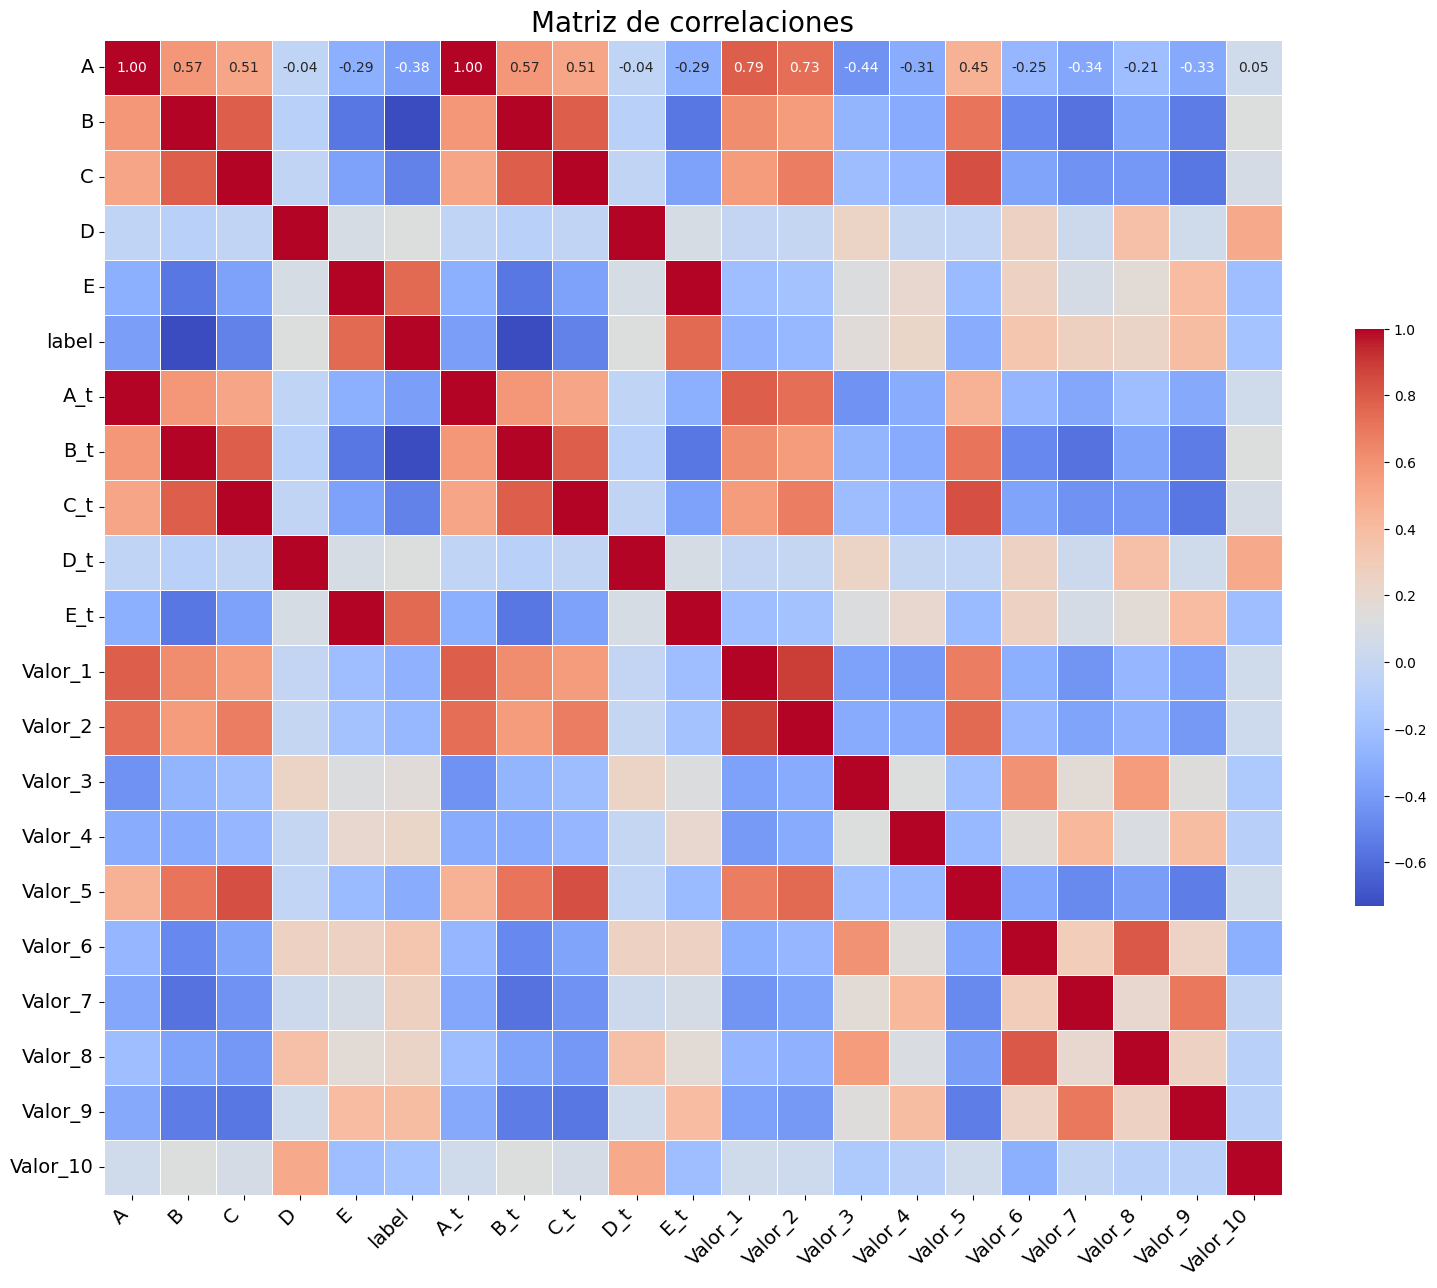

In [24]:
# Calculamos la matriz de correlaciones
corr = data_EDA.corr()

# Set up the heatmap
f, ax = plt.subplots(figsize=(19, 15))
sns.heatmap(corr, annot=True, ax=ax, cmap='coolwarm', fmt=".2f", 
            linewidths=.5, cbar_kws={"shrink": .5})
plt.xticks(rotation=45, ha='right', fontsize=14)
plt.yticks(rotation=0, fontsize=14)
plt.title('Matriz de correlaciones', fontsize=20)
plt.show()


Matriz de correlacion de variable label:


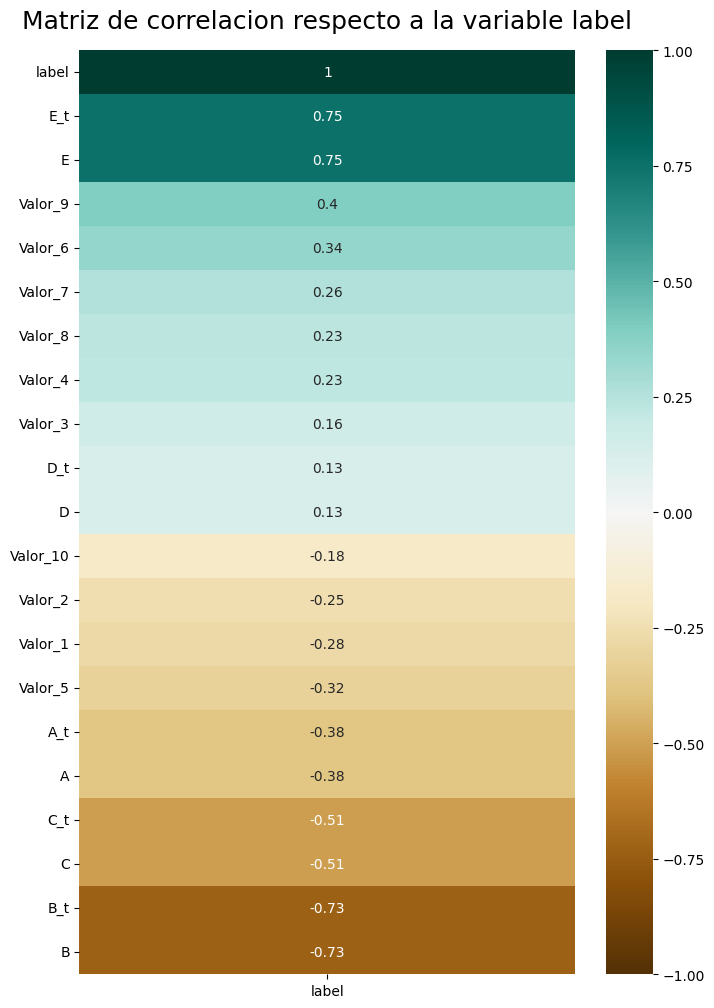

In [25]:
variables = list(data_EDA.columns)

# Matriz de correlacion respecto de la variable C6H6
print("\nMatriz de correlacion de variable label:")
columnas_a_utilizar = data_EDA[variables]
plt.figure(figsize=(8, 12))
heatmap = sns.heatmap(data_EDA.corr()[['label']].sort_values(by='label', ascending=False), vmin=-1, vmax=1, annot=True, cmap='BrBG')
heatmap.set_title('Matriz de correlacion respecto a la variable label', fontdict={'fontsize':18}, pad=16);
plt.show()

Vemos que las variables B y C (normalizada y sin normalizar) presentan una correlacion negativa fuerte con la variable objetivo, asi como fuerte y positiva la vabiable E.

_GENERACION DE COLUMNAS DE CLASIFICACION_

label
0.0    5000
1.0    5000
Name: count, dtype: int64


AttributeError: Rectangle.set() got an unexpected keyword argument 'legend'

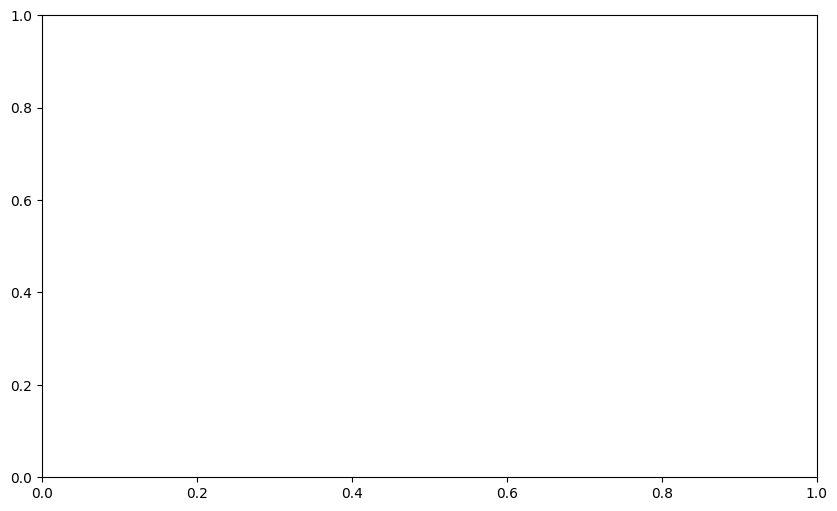

In [41]:
# Obtener la distribución de las etiquetas de clase
distribucion_clases = data_EDA['label'].value_counts()

# Mostrar la distribución
print(distribucion_clases)

# Graficar la distribución de etiquetas de clase
plt.figure(figsize=(10, 6))
#sns.barplot(x=distribucion_clases.index, y=distribucion_clases.values, palette='viridis')
sns.barplot(x=distribucion_clases.index, y=distribucion_clases.values, hue=distribucion_clases.index, palette='viridis', legend=False)
plt.title('Distribución de Etiquetas de Clase (label)')
plt.xlabel('Clase')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.show()

### 4. Implementación de modelo utilizando el algoritmo Gradient Boosting Tree

Gradient Boosting Tree en un algoritmo de aprendizaje supervisado basado en la técnica boosting, que combina árboles débiles en secuencia para formar un modelo muy consistente. Su funcionamiento consiste en entrenar un primer árbol y calcular los errores entre predicciones y valores reales. Después, se entrena el segundo árbol para corregir estos errores, repitiendo el proceso hasta que el error se va mejorando.

A nivel interno, el algoritmo trata de buscar mínimos locales, con el objetivo de encontrar la solución óptima en el hiperplano de las variables. De esta manera, en cada iteración busca el gradiente en dicho hiperplano, de ahí su nombre. Su objetivo es encontrar el mínimo global en el hiperplano, aunque esto no siempre ocurre.

1. Eleccion de columnas predictoras

In [28]:
df = data_EDA

In [ ]:
# eleccion de columnas predictoras y columna target

X = df.drop(columns=['label'])
y = df['label']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_test = train_test_split(X, y , test_size=0.3, random_state=42)

Se considera que un 20% es suficiente para datos de validación. Además, menos de un 80% de datos de entrenamiento quizá no sería suficiente para entrenar el modelo y podría producirse underfitting.

Para probar varias implementaciones del algoritmo, se va a realizar una grid search. Esto es una técnica en la que se implementarán varios modelos gradient boosting tree con diferentes hiperparámetros. Se van a explorar combinaciones de los siguientes hiperparámetros:
- n_estimators: Se refiere al número total de árboles en cada modelo. Un número muy alto puede cargar demasiado computacionalmente.
- learning_rate: es la tasa de convergencia según el punto de hiperplano en el que se encuentre. Un valor muy bajo podría no permitir al modelo salir de un mínimo local, mientraas que un valor alto impediría al modelo converger en ninguno.
- max_depth: máxima profundidad de los árboles.

In [36]:
n_estimators= [10, 20, 50]
learning_rates= [0.05, 0.1]
max_depth= [1, 3, 5]

In [35]:
results=[]

A continuación se itera el modelo utilizando todos las combinaciones de hiperparámetros, y se introducen en la lista de resultados todas las métricas que se van a emplear.

Se generará un modelo para cada combinación, y se agregarán las métricas, así como las matrices de confusióna la lista de resultados.

In [37]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix

for lr in learning_rates:
    for depth in max_depth:
        for n_trees in n_estimators:
            gbt = GradientBoostingClassifier(learning_rate=lr, max_depth=depth, n_estimators=n_trees, random_state=42)
            
            gbt.fit(X_train, y_train)
            
            y_pred = gbt.predict(X_val)
            
            f1 = f1_score(y_test, y_pred)
            precision = precision_score(y_test, y_pred)
            recall = recall_score(y_test, y_pred)
            conf_matrix = confusion_matrix(y_test, y_pred)
            
            results.append({
                "learning_rate": lr,
                "max_depth": depth,
                "n_estimators": n_trees,
                "f1_score": f1,
                "precision": precision,
                "recall": recall,
                "conf_matrix": conf_matrix
            })

Las metricas utilizadas para evaluar los modelos serán las siguientes:

1. Precision: Mide qué proporción de los mensajes que el modelo clasificó como de una clase concreta, por ejemplo, de odio, de los que realmente lo son. Esta métrica es muy útil en el caso que se tiene porque si es baja significa, por ejemplo, que el modelo está clasificando incorrectamente demasiados mensajes de odio (serían falsos positivos). Esto puede ser un problema, ya que podría reportar y bloquear cuentas que publiquen ciertos mensajes clasificándolos como odio cuando en realidad no lo son.
2. Recall: Esta métrica mide qué proporción de los mensajes de odio reales fueron clasificados bien. Es, en parte, la inversa a la métrica anterior. Si el recall es bajo puede ser que el modelo esté fallando en detectar muchos mensajes de odio, lo cual puede ser un gran problema si el objetivo es evitar la propagación de mensajes de odio en una plataforma o red social.
3. F1-score: Esta métrica realiza la media armónica de precision y recall. Es muy potente porque combina las ventajas de ambas. En un problema de clases desbalanceadas es muy útil, además de que permite capturar, como se ha dicho, las ventajas de ambas métricas con una sola.
4. Matriz de confusión: La matriz de confusión no es una métrica como tal, sino una tabla que permite ver dónde han sido clasificadas las instancias de cada clase, y ayuda a visualizar si el modelo está sesgado hacia alguna clase en particular o si los errores se distribuyen uniformemente.

Entre las tres primeras, se tomará como referencia que el mejor modelo será aquel que aporte un mejor f1-score, ya que como se ha explicado, combina las ventajas de precision y recall, por lo que en el siguiente fragmento de código se mostrarán todos los resultados obtenidos ordenados de forma descendente según esta métrica.

In [40]:
results_df = pd.DataFrame(results)

results_df.sort_values(by="f1_score", ascending=False, inplace=True)

print(results_df)

    learning_rate  max_depth  n_estimators  f1_score  precision    recall  \
16           0.10          5            20  0.982958   0.980286  0.985646   
15           0.10          5            10  0.982947   0.980939  0.984962   
14           0.10          3            50  0.982935   0.981595  0.984279   
7            0.05          5            20  0.982612   0.980272  0.984962   
8            0.05          5            50  0.982277   0.979606  0.984962   
6            0.05          5            10  0.982040   0.973790  0.990431   
17           0.10          5            50  0.981930   0.979592  0.984279   
13           0.10          3            20  0.979898   0.976902  0.982912   
5            0.05          3            50  0.979578   0.975593  0.983595   
12           0.10          3            10  0.978172   0.976174  0.980178   
3            0.05          3            10  0.977899   0.972936  0.982912   
4            0.05          3            20  0.977808   0.976808  0.978811   

Para realizar la evaluación, se han tomado como referencia las predicciones sobre los datos de validación, que el modelo no ha visto durante el entrenamiento.

Con ello, se estará probando cómo el modelo responde ante datos nuevos. Se ha obtenido que el mejor modelo es la combinación de learning rate = 0.1; depth = 5; y numero de arboles = 20. Atendiendose a los resultados, se observa que el modelo en general va mejorando segun la maxima profundidad permitida, ya que los modelos con profundidad igual a 1 son los que peor funcionan, y como se observa en la matriz de confusión, tienden a clasificar hacia una de las dos clases, mientras que para  modelos con mayor profundidad tienen menor sesgo y tienen los errores más balanceados.
También se podría aprobar la teoría de que a partir de los 20 árboles o tras los 50 se comienza a producir overfitting, y es por ello que el modelo obtiene mejores resultados con 20 que con 50 estimadores.

Con todo ello en cuenta, se obtiene que el mejor modelo utilizando el algoritmo Gradient Boosting Tree es:

- lr = 0.1
- depth = 5
- n_trees = 20

con unas metricas de:
- f1 = 0.982958 
- prec = 0.980286
- recall = 0.985646

Estas métricas son muy buenas, y en general, todas las combinaciones obtienen métricas muy altas. Este es en definitica un muy buen algoritmo para este problema concreto